In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_products_bought_together.csv to retail_products_bought_together.csv


  Transaction_ID Product_ID Product_Category  Quantity
0          T0001       P006              Dal         3
1          T0001       P002             Milk         2
2          T0002       P010            Sugar         3
3          T0002       P001            Bread         3
4          T0002       P003           Butter         2

Total Transactions: 500


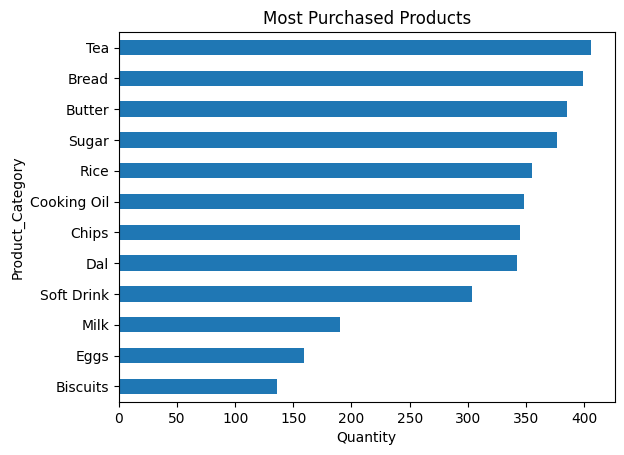


Frequently Bought Together:
      Product1    Product2  Count
0        Bread      Butter    149
1        Sugar         Tea    136
2  Cooking Oil         Dal    118
3          Dal        Rice    115
4  Cooking Oil        Rice    115
5        Chips  Soft Drink     97
6        Bread         Tea     87
7        Bread       Sugar     84
8          Dal         Tea     79
9         Rice         Tea     79

Top Product Associations:
       Product1    Product2  Support  Confidence      Lift
2   Cooking Oil         Dal    0.236    0.666667  1.915709
5         Chips  Soft Drink    0.194    0.580838  1.885839
0         Bread      Butter    0.298    0.726829  1.863665
3           Dal        Rice    0.230    0.660920  1.825745
4   Cooking Oil        Rice    0.230    0.649718  1.794800
1         Sugar         Tea    0.272    0.719577  1.746545
36          Dal        Milk    0.078    0.224138  1.192223
14          Dal       Sugar    0.146    0.419540  1.109895
8           Dal         Tea    0.158   

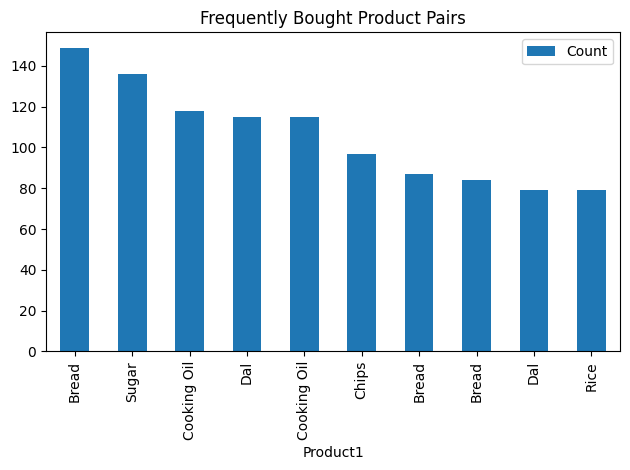

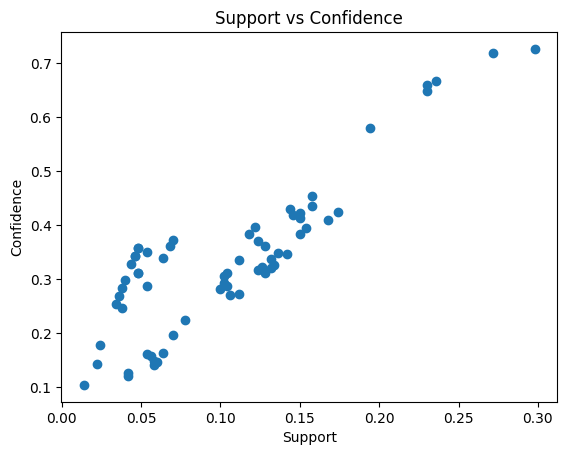

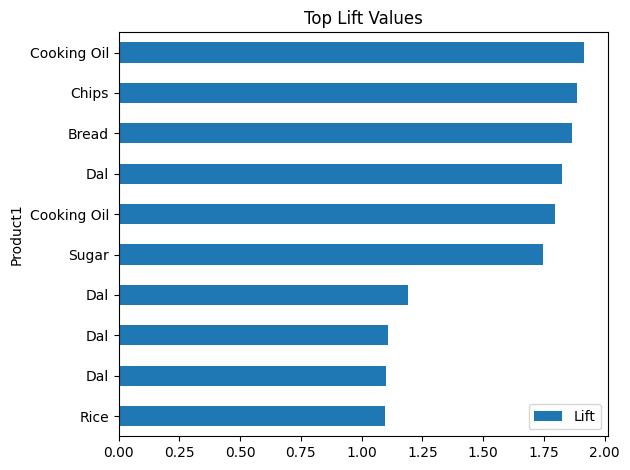


KNN Accuracy: 0.7857142857142857

Recommended Product Bundles:
      Product1    Product2      Lift
2  Cooking Oil         Dal  1.915709
5        Chips  Soft Drink  1.885839
0        Bread      Butter  1.863665


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load and clean
df = pd.read_csv("retail_products_bought_together.csv")
df = df.dropna().drop_duplicates()

print(df.head())
print("\nTotal Transactions:", df["Transaction_ID"].nunique())

# --------------------
# VISUALIZATION 1
# --------------------
top = df.groupby("Product_Category")["Quantity"].sum().sort_values()

top.plot(kind="barh")
plt.title("Most Purchased Products")
plt.xlabel("Quantity")
plt.show()

# --------------------
# Find product pairs
# --------------------
baskets = df.groupby("Transaction_ID")["Product_Category"].apply(list)

pairs = []

for basket in baskets:
    for pair in combinations(sorted(set(basket)), 2):
        pairs.append(pair)

pair_df = pd.DataFrame(pairs, columns=["Product1", "Product2"])

pair_counts = pair_df.value_counts().reset_index(name="Count")

print("\nFrequently Bought Together:")
print(pair_counts.head(10))

# --------------------
# Support, Confidence, Lift
# --------------------
total = len(baskets)

results = []

for _, row in pair_counts.iterrows():

    a = row["Product1"]
    b = row["Product2"]
    both = row["Count"]

    count_a = sum(a in x for x in baskets)
    count_b = sum(b in x for x in baskets)

    support = both / total
    confidence = both / count_a
    lift = confidence / (count_b / total)

    results.append([a, b, support, confidence, lift])

rules = pd.DataFrame(
    results,
    columns=["Product1", "Product2",
             "Support", "Confidence", "Lift"]
)

print("\nTop Product Associations:")
print(rules.sort_values("Lift", ascending=False).head(10))

# --------------------
# VISUALIZATION 2
# --------------------
pair_counts.head(10).plot(
    x="Product1",
    y="Count",
    kind="bar"
)
plt.title("Frequently Bought Product Pairs")
plt.tight_layout()
plt.show()

# --------------------
# VISUALIZATION 3
# --------------------
plt.scatter(rules["Support"], rules["Confidence"])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# --------------------
# VISUALIZATION 4
# --------------------
rules.sort_values("Lift").tail(10).plot(
    x="Product1",
    y="Lift",
    kind="barh"
)
plt.title("Top Lift Values")
plt.tight_layout()
plt.show()

# --------------------
# KNN MODEL
# --------------------
X = rules[["Support", "Confidence"]]
y = (rules["Lift"] > 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

print("\nKNN Accuracy:",
      accuracy_score(y_test, prediction))

# --------------------
# TOP 3 BUNDLES
# --------------------
print("\nRecommended Product Bundles:")

print(
    rules.sort_values("Lift", ascending=False)
    .head(3)[["Product1", "Product2", "Lift"]]
)